# 02 – EDA and Visualisations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("faults_with_missing(1).csv")
TARGET_COLS = ["Pastry","Z_Scratch","K_Scatch","Stains","Dirtiness","Bumps","Other_Faults"]
df["Fault_Type"] = df[TARGET_COLS].idxmax(axis=1)
FEATURE_COLS = [c for c in df.columns if c not in TARGET_COLS + ["Fault_Type"]]

class_counts = df["Fault_Type"].value_counts()

## Target Distribution

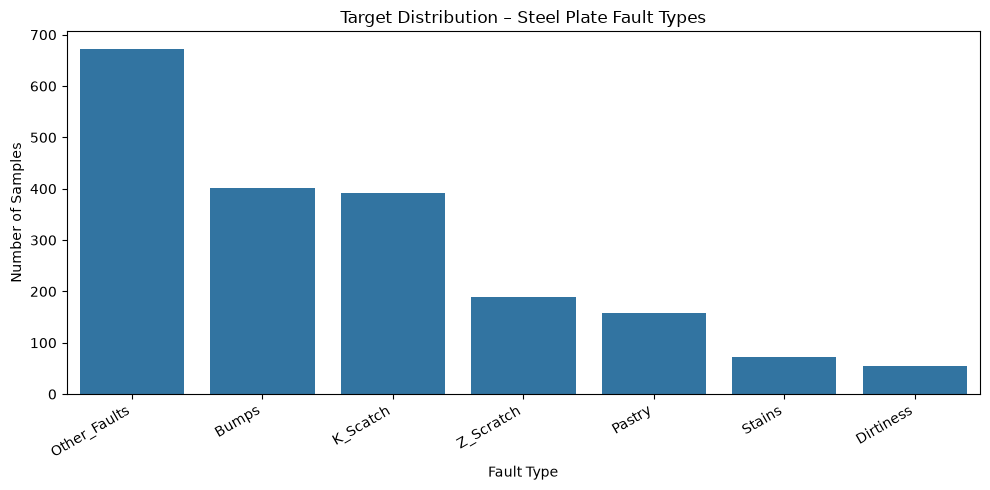

In [2]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Fault_Type", order=class_counts.index)
plt.title("Target Distribution – Steel Plate Fault Types")
plt.xlabel("Fault Type")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Observation
The target distribution is imbalanced: some fault types have considerably more observations than others. This makes stratified splitting and weighted evaluation metrics important.

## Feature Distributions – Features 1–9

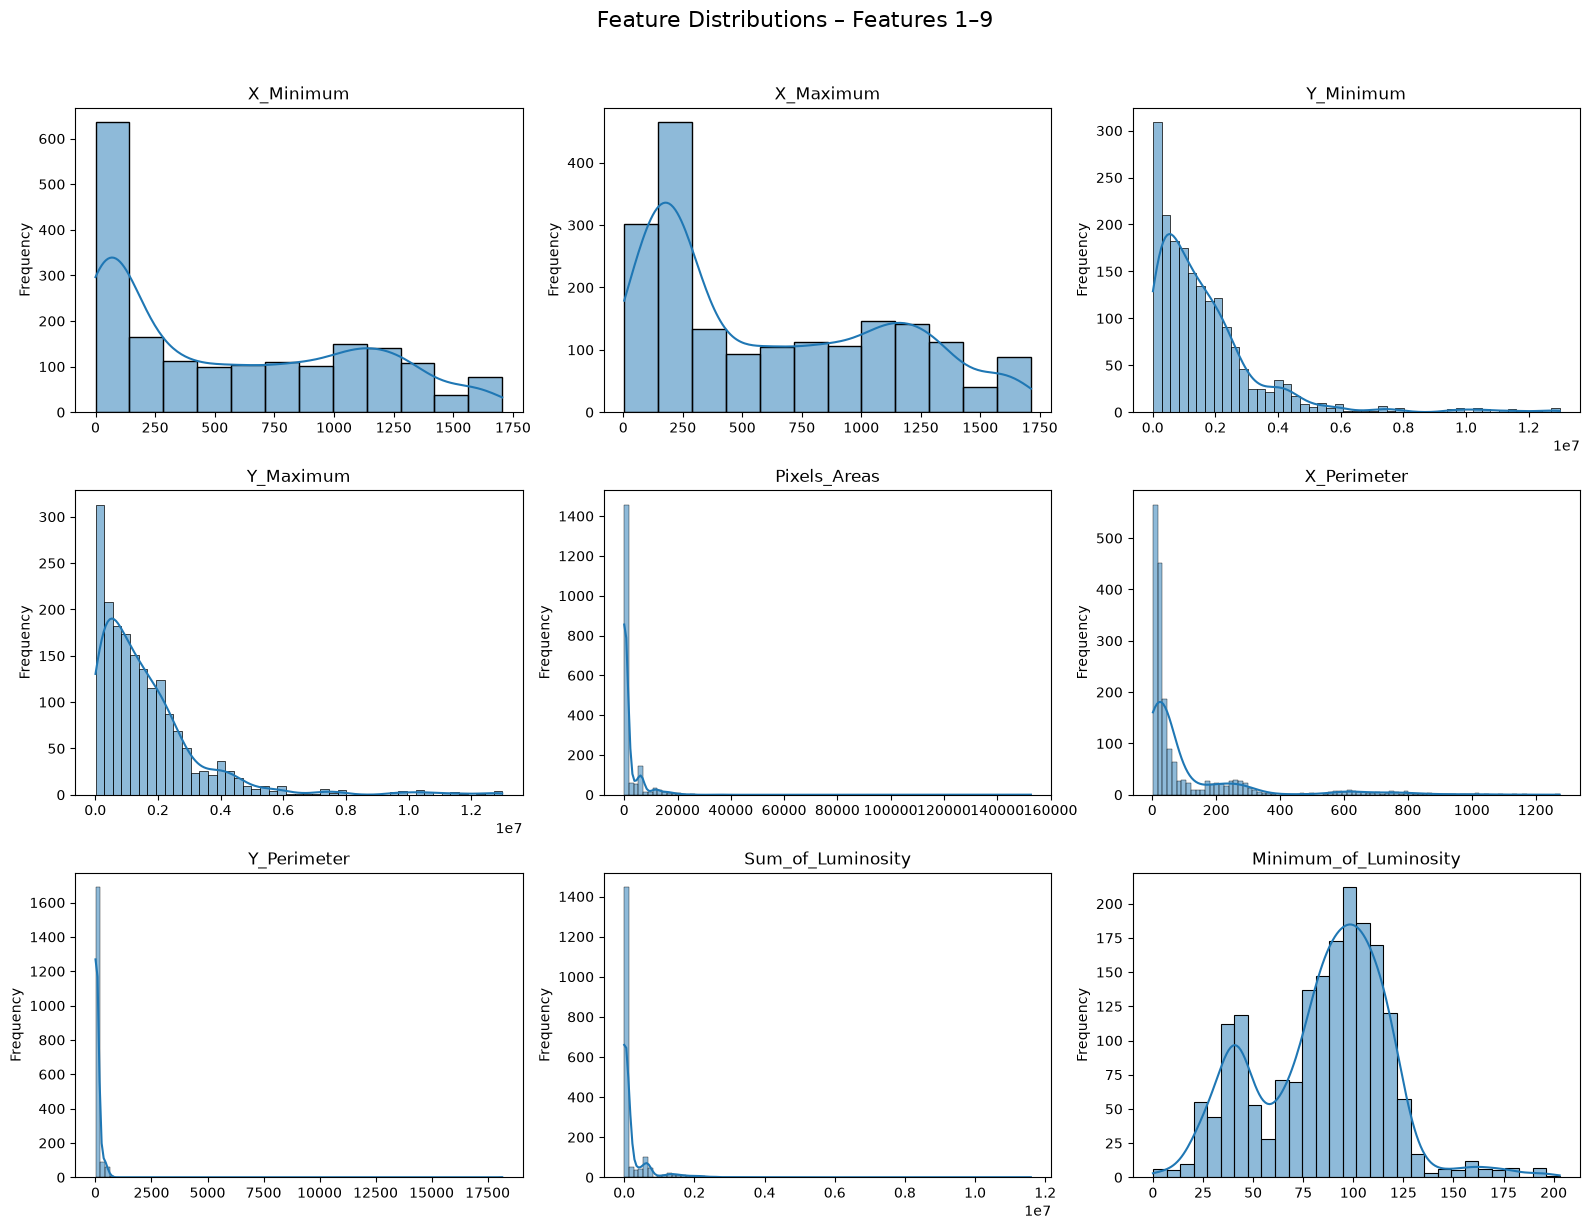

In [3]:
fig, axes = plt.subplots(3,3, figsize=(16,12))
axes = axes.flatten()
for ax, col in zip(axes, ['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity']):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")
for ax in axes[len(['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity']):]:
    ax.axis("off")
plt.suptitle("Feature Distributions – Features 1–9", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Observation
These features have different ranges and shapes. Several continuous variables are skewed or long-tailed, showing why imputation, outlier treatment and scaling are useful before classification.

## Feature Distributions – Features 10–18

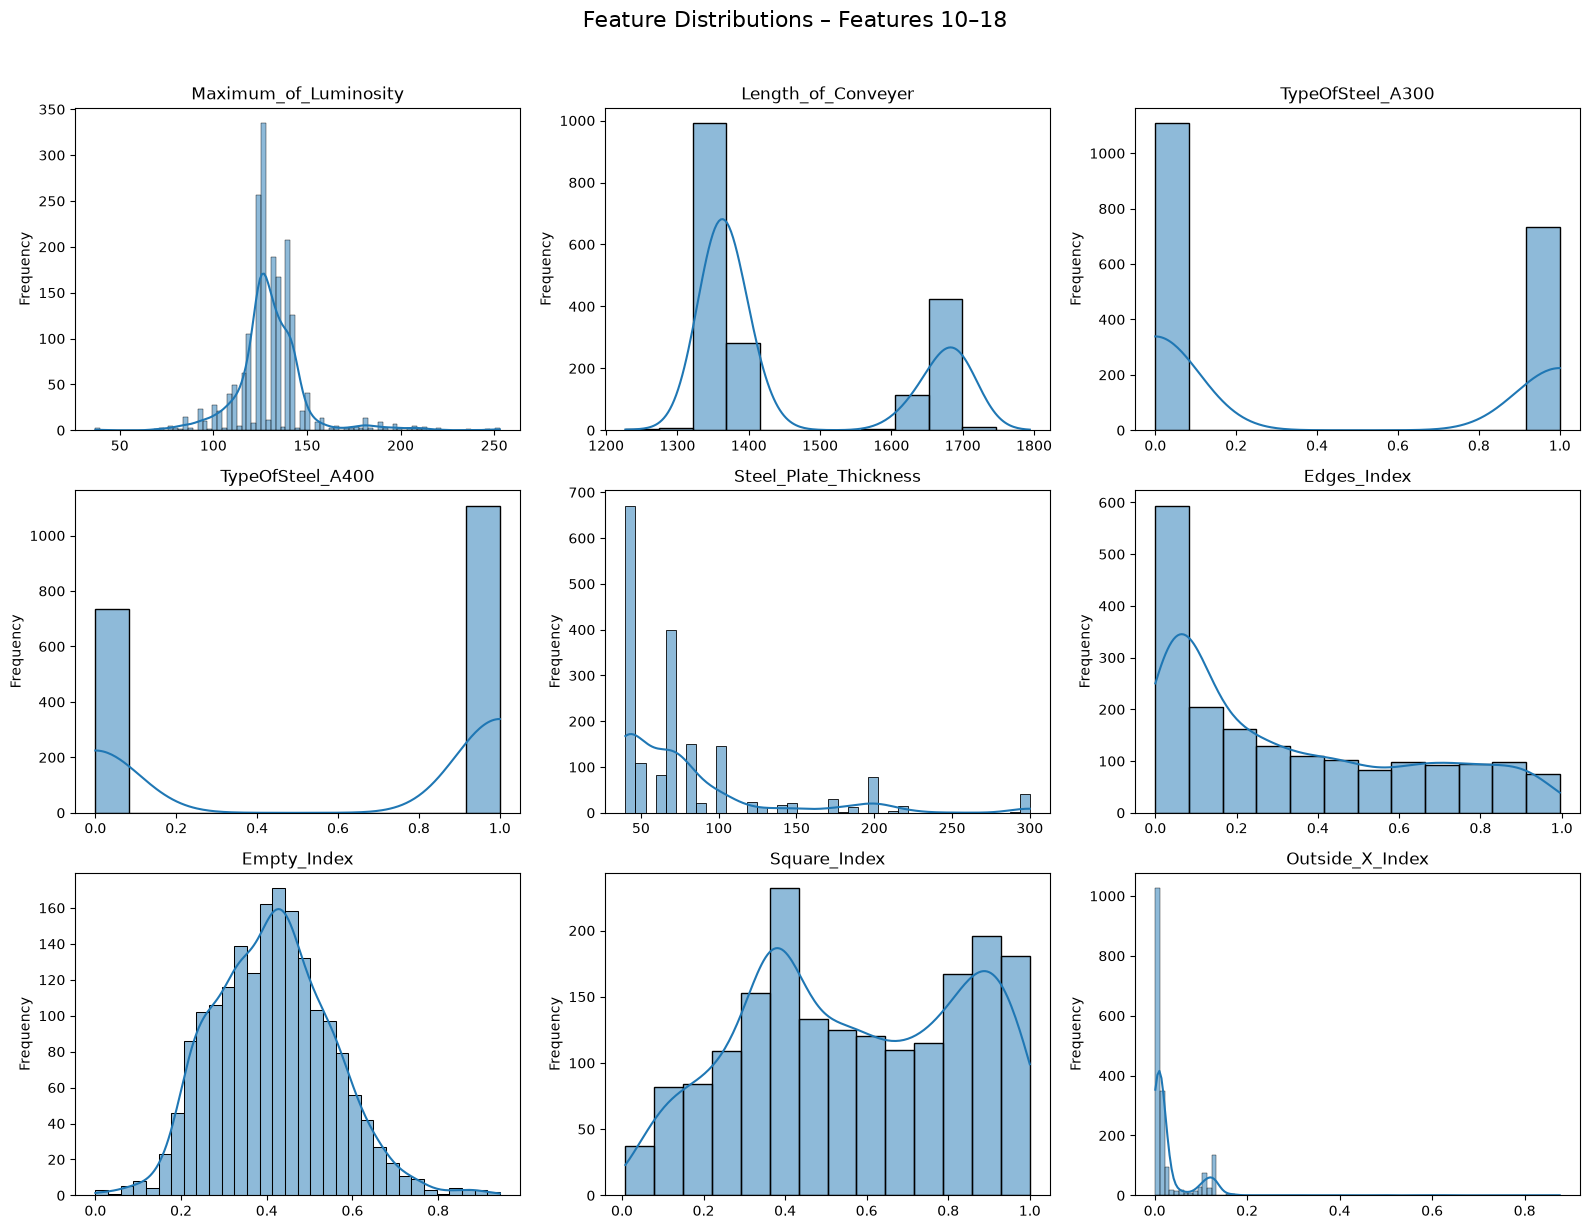

In [4]:
fig, axes = plt.subplots(3,3, figsize=(16,12))
axes = axes.flatten()
for ax, col in zip(axes, ['Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index']):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")
for ax in axes[len(['Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index']):]:
    ax.axis("off")
plt.suptitle("Feature Distributions – Features 10–18", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Observation
These features have different ranges and shapes. Several continuous variables are skewed or long-tailed, showing why imputation, outlier treatment and scaling are useful before classification.

## Feature Distributions – Features 19–27

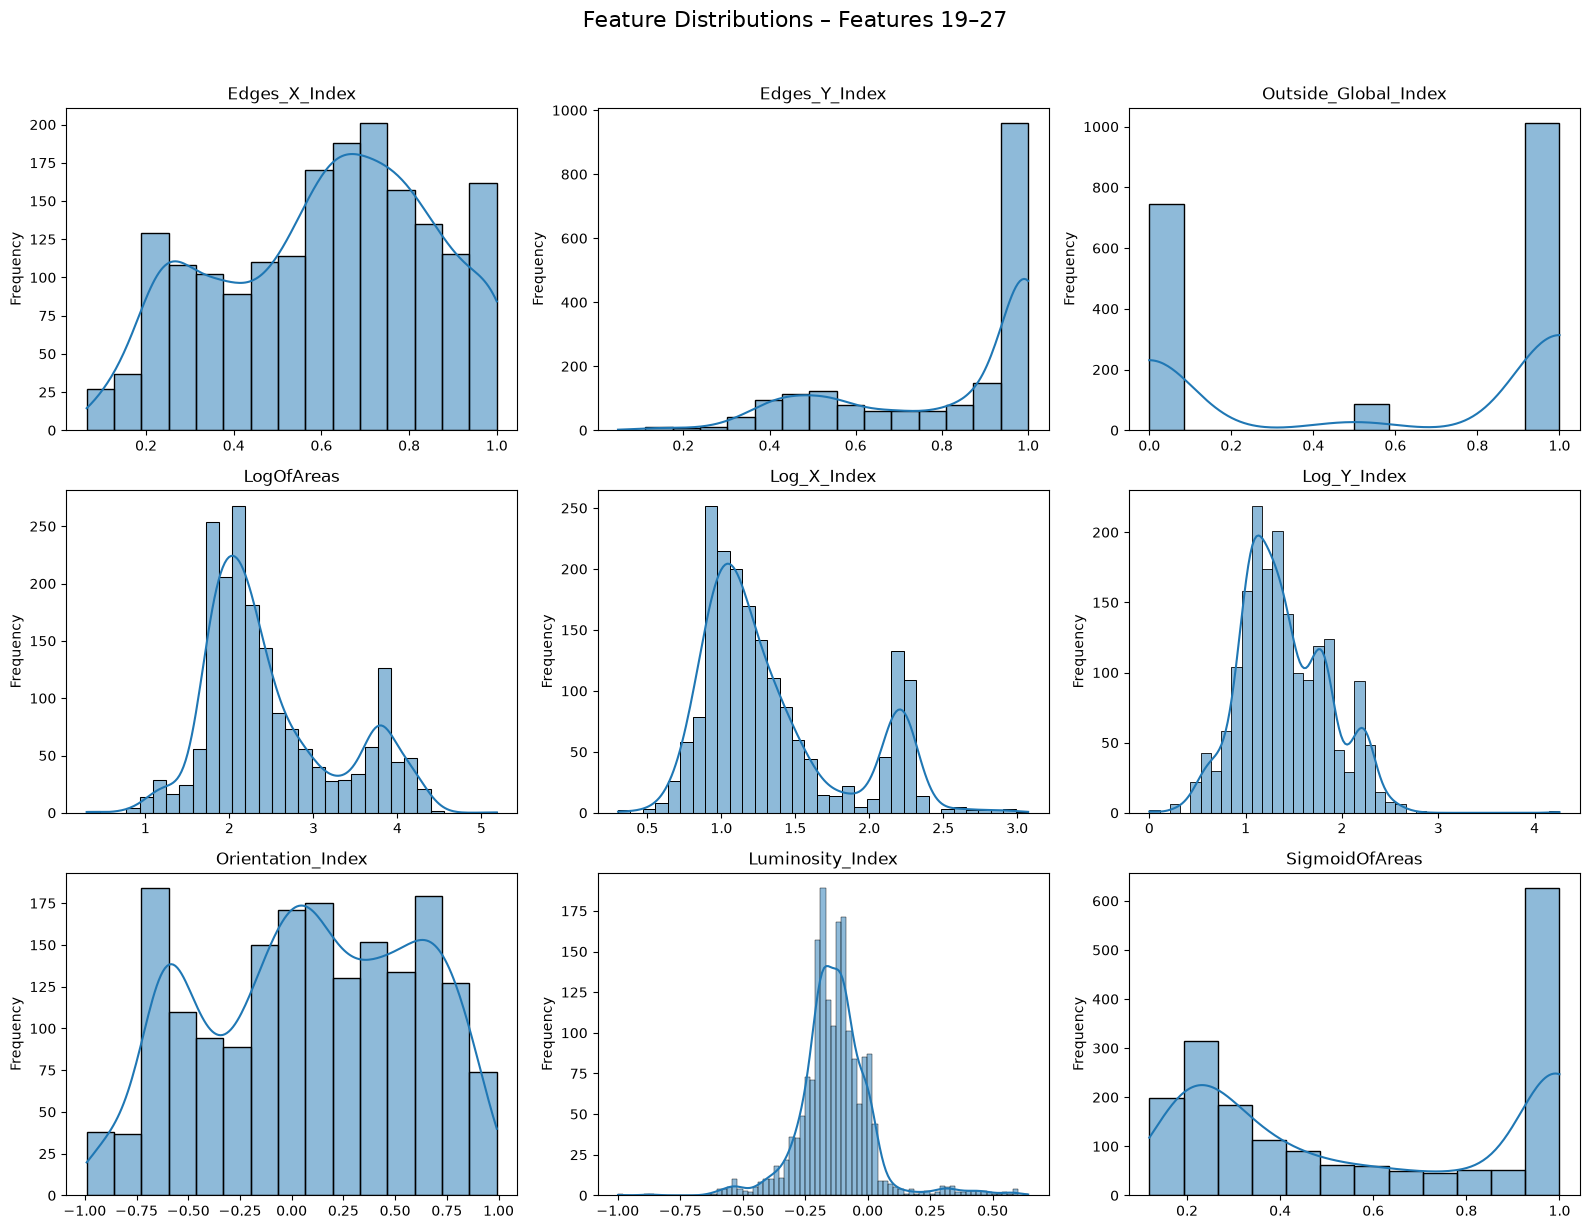

In [5]:
fig, axes = plt.subplots(3,3, figsize=(16,12))
axes = axes.flatten()
for ax, col in zip(axes, ['Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas']):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")
for ax in axes[len(['Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas']):]:
    ax.axis("off")
plt.suptitle("Feature Distributions – Features 19–27", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Observation
These features have different ranges and shapes. Several continuous variables are skewed or long-tailed, showing why imputation, outlier treatment and scaling are useful before classification.

## Correlation Heatmap

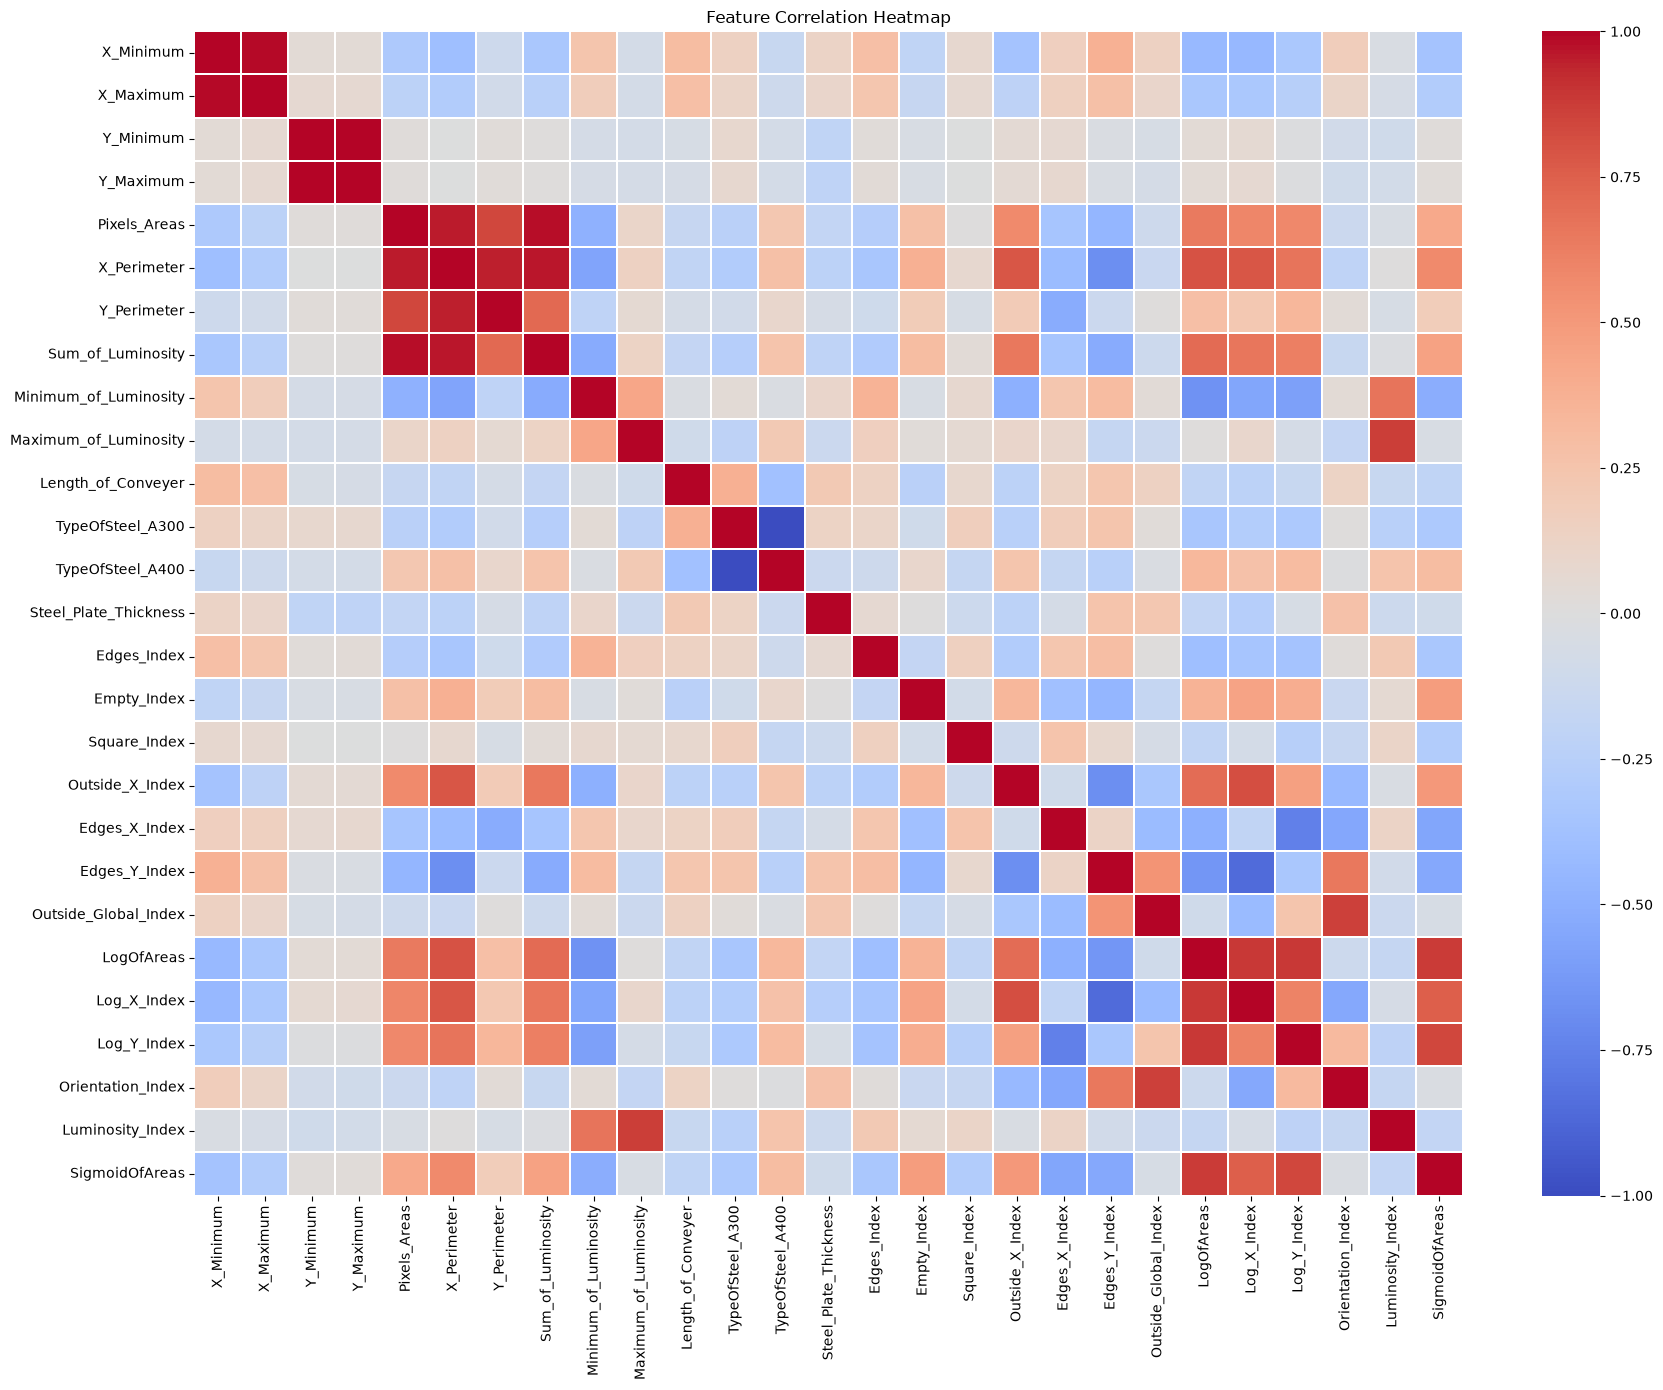

,abs_corr,correlation,feature_1,feature_2
231,1.000000,-1.000000,TypeOfSteel_A300,TypeOfSteel_A400
51,1.000000,1.000000,Y_Minimum,Y_Maximum
0,0.987613,0.987613,X_Minimum,X_Maximum
100,0.978735,0.978735,Pixels_Areas,Sum_of_Luminosity
121,0.961460,0.961460,X_Perimeter,Sum_of_Luminosity
98,0.959066,0.959066,Pixels_Areas,X_Perimeter
120,0.952668,0.952668,X_Perimeter,Y_Perimeter
336,0.889304,0.889304,LogOfAreas,Log_X_Index
337,0.883710,0.883710,LogOfAreas,Log_Y_Index
340,0.875990,0.875990,LogOfAreas,SigmoidOfAreas


In [6]:
corr = df[FEATURE_COLS].corr(numeric_only=True)
plt.figure(figsize=(18,14))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

pairs=[]
for i,c1 in enumerate(FEATURE_COLS):
    for c2 in FEATURE_COLS[i+1:]:
        v=corr.loc[c1,c2]
        if pd.notna(v):
            pairs.append((abs(v),v,c1,c2))
display(pd.DataFrame(pairs,columns=["abs_corr","correlation","feature_1","feature_2"])
        .sort_values("abs_corr",ascending=False).head(10))

### Observation
The heatmap reveals several strongly correlated measurements. In particular, area/luminosity and coordinate/perimeter measurements contain related information, indicating redundancy among some predictors.

## Scatter Plot 1 – Feature vs Target

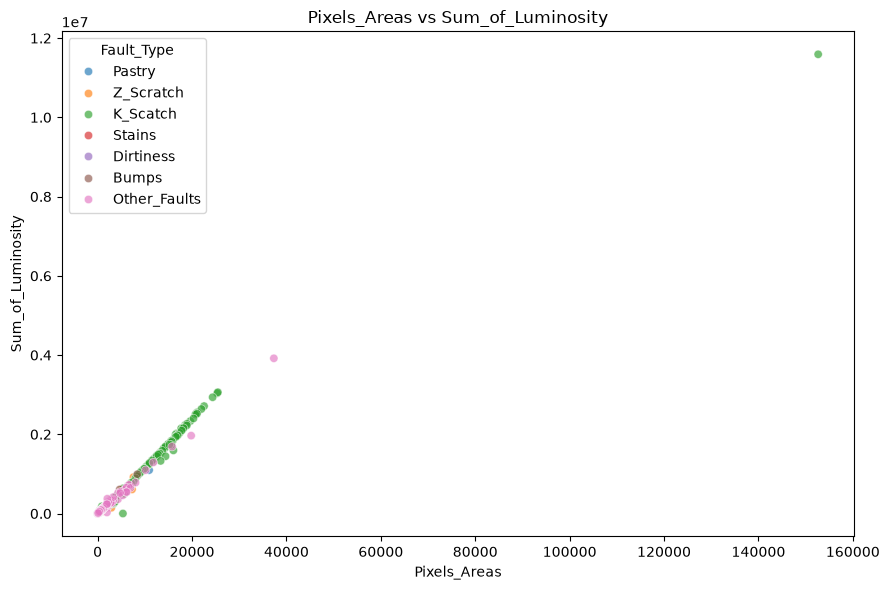

In [7]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="Pixels_Areas", y="Sum_of_Luminosity",
                hue="Fault_Type", alpha=0.65)
plt.title("Pixels_Areas vs Sum_of_Luminosity")
plt.tight_layout()
plt.show()

### Observation
`Pixels_Areas` and `Sum_of_Luminosity` show a strong positive relationship. The fault classes still overlap, so these two measurements alone do not perfectly separate the classes.

## Scatter Plot 2 – Feature vs Target

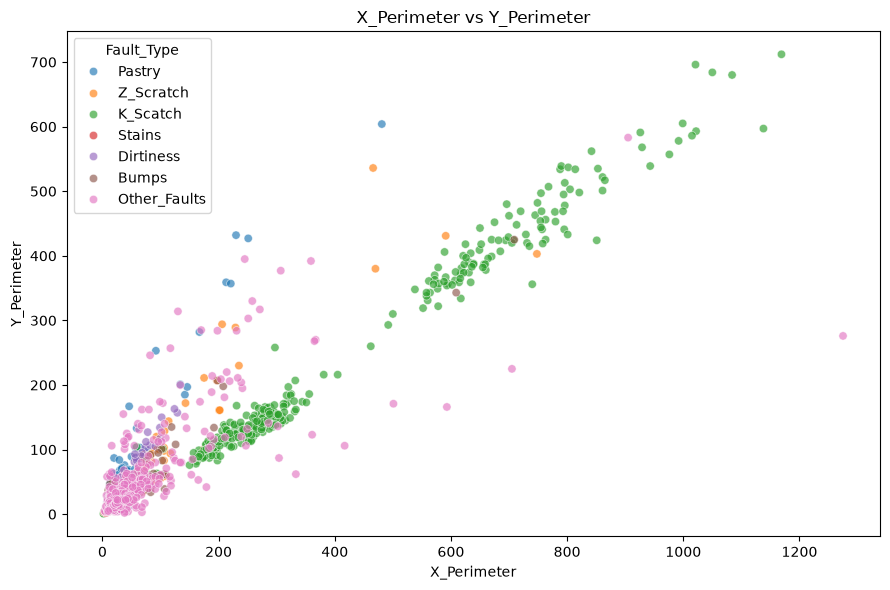

In [8]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=df, x="X_Perimeter", y="Y_Perimeter",
                hue="Fault_Type", alpha=0.65)
plt.title("X_Perimeter vs Y_Perimeter")
plt.tight_layout()
plt.show()

### Observation
`X_Perimeter` and `Y_Perimeter` are positively related, but the classes overlap substantially. Multiple predictors are therefore needed for reliable multiclass classification.